# Balance of Power — a quantitative teardown 🔬
### Smoothed BOP zero up-cross on 5 indices · forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a sign-scramble ordering placebo · costs · a synthetic planted-lead control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_buyer/seller_balance_forecast%3F: Busted](https://img.shields.io/badge/Does_buyer%2Fseller_balance_forecast%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **indicator** from the **drift**: an upward-trending index makes *any* long-only entry look good, so the only meaningful test is cross-vs-random, plus a placebo that destroys the BOP series' time ordering while preserving its marginal.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. BOP = (close−open)/(high−low), smoothed with a causal 14-day MA; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from balance_of_power import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real BOP cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1631, 'smooth': 14, 'fp_spy': '4cb5244f3990', 'h5': (5, 1626, 17.8, 57, 2.37, 13.9, 3.9, 15.8, 0.42, 0.678), 'h10': (10, 1626, 39.8, 59, 3.57, 36.5, 3.2, 37.8, 0.26, 0.798), 'h20': (20, 1624, 73.9, 59, 4.08, 81.8, -7.9, 71.9, -0.43, 0.666), 'h60': (60, 1617, 273.7, 68, 6.13, 306.3, -32.6, 271.7, -1.08, 0.281), 'per': [('SPY', 304, 23.6, 0.61, 105.4, -81.8), ('QQQ', 320, 104.2, 2.84, 130.5, -26.4), ('IWM', 382, 66.2, 1.51, 6.1, 60.1), ('DIA', 316, 55.2, 1.69, 65.9, -10.7), ('GLD', 309, 120.6, 3.12, 118.3, 2.3)], 'placebo': (23.6, 0.994, 500), 'syn': [(0.0, 238, 5.7, 50, 0.14), (1.5, 129, 281.7, 69, 3.19)]}


real BOP cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | BOP up-cross vs a **drift-matched random** baseline: a dead heat at 5/10d (Δ = +4/+3 bps) and *worse* at 20/60d (Δ = -8/-33 bps); the cross-minus-random difference **never clears t = 2** (max Welch t = +0.42 at 5d). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 4.08, 60d = 6.13) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Does buyer/seller balance forecast?** | `BUSTED` | Scrambling the BOP series' time ordering (sign-scramble placebo) leaves the result intact: **p = 0.99** of nonsense orderings match or beat the real one. The sequence isn't doing the work. |

> 💡 In plain words: the BOP cross *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the time order (scramble the readings) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Define the per-bar balance $b_t = (C_t - O_t)/(H_t - L_t) \in [-1,1]$ and its causal smoothing $\bar b_t = \frac1{m}\sum_{j=0}^{m-1} b_{t-j}$ (here $m=14$). The Livshin rule buys on the **zero up-cross** $\bar b_{t-1} < 0 \le \bar b_t$ and expects a forward rise.

- **H₀ (drift).** Cross returns equal a drift-matched **random-entry** baseline.
- **H₁ (BOP leads).** Cross returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the ordering matters).** Cross returns exceed a **sign-scramble** BOP whose readings are time-shuffled.

We find **H₀ not rejected** (cross ≤ random at 20–60d, tie at 5–10d), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.99). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only entry rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of cross-*minus*-random.

**(b) Spurious sequence structure.** A smoothed BOP cross is just a function of recent bar bodies; the danger is that *any* trailing average of a trending series crosses zero right before more trend. The **sign-scramble placebo** keeps the BOP marginal but permutes the readings in time — the smoothed series and its crosses become meaningless, so if the real result survives the scramble, the time ordering was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **1631 BOP up-crosses** pooled.
- **Indicator.** BOP = (close−open)/(high−low), range-guarded, clipped to [−1,1]; smoothed with a causal 14-day SMA (no look-ahead).
- **Entry.** Zero up-cross (smoothed BOP negative on *t−1*, ≥ 0 on *t*); enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of cross returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample cross vs random (the *real* test).
- **Null #3 — sign-scramble placebo** (BOP time order destroyed, marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every cross.
- **Positive control.** Synthetic tape with a **planted** BOP-leads-price structure (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the BOP cross's **one-sample** t against zero (the misleading number). Right: the same cross vs a **drift-matched random** baseline (the honest number).

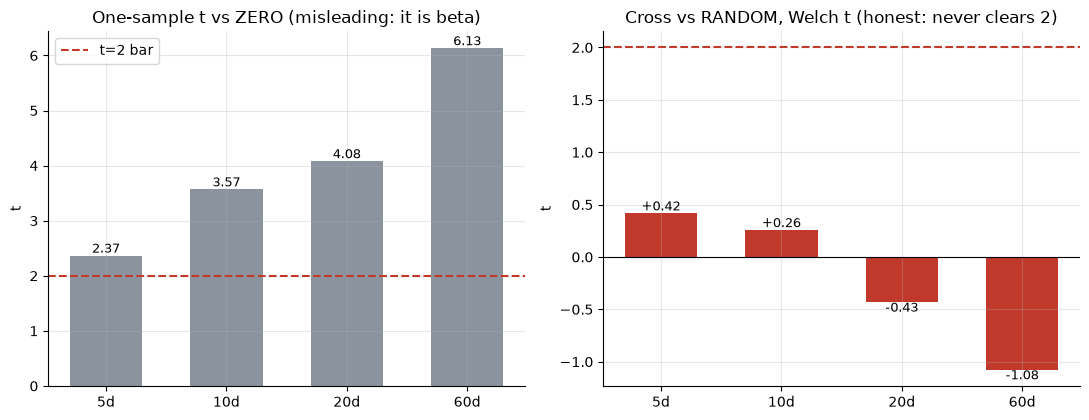

one-sample t: [2.37, 3.57, 4.08, 6.13]
welch vs random: [np.float64(0.42), np.float64(0.26), np.float64(-0.43), np.float64(-1.08)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, cross, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.bop_cross_entries(bb, smooth=R['smooth'])
            re = st.random_entries(bb, max(len(e),50), smooth=R['smooth'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); cross.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Cross vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **4.08**, 60d **6.13**) — but that's the **drift**, every long-only entry inherits it. The right bars are the real test: cross-minus-random is **near zero** at 5/10d and **negative** at 20/60d (-1.08 at 60d) — never significant. The indicator adds nothing over a coin flip.

### 4b · Cross vs random across horizons — the gap is the verdict

Mean return, BOP cross vs random entry, all four horizons. The cross should tower over random if BOP leads. It doesn't.

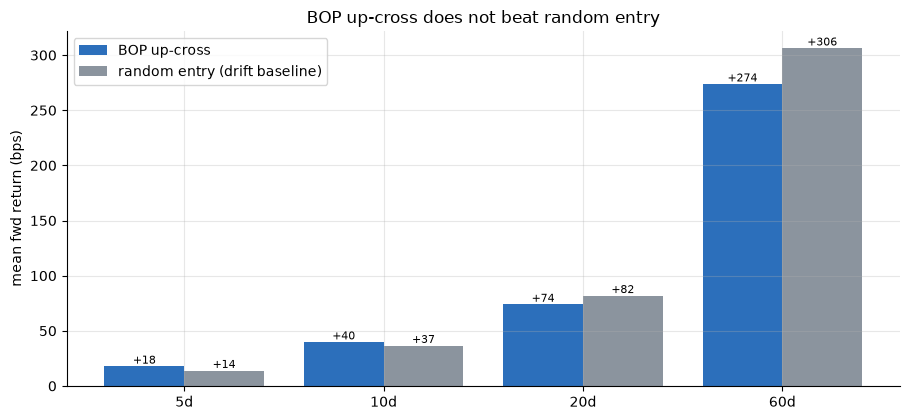

delta cross-random (bps): [4, 3, -8, -33]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='BOP up-cross')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('BOP up-cross does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta cross-random (bps):', [round(a-b) for a,b in zip(cross,rnd)])

> 💡 In plain words: at 20 days the cross is **+74 bps** but random is **+82 bps** — the indicator *underperforms* a dart by 8 bps. At 5/10 days it's a tie. There is no horizon where BOP convincingly leads.

### 4c · The ordering placebo — scramble the BOP, nothing changes

Shuffle the per-bar BOP readings in time (marginal kept) so the smoothed series and its crosses are temporally meaningless. If price respects *this specific sequence*, the scramble should demolish the result. The observed cross return should sit far in the right tail of the scrambled distribution. It doesn't — it sits in the *left* tail.

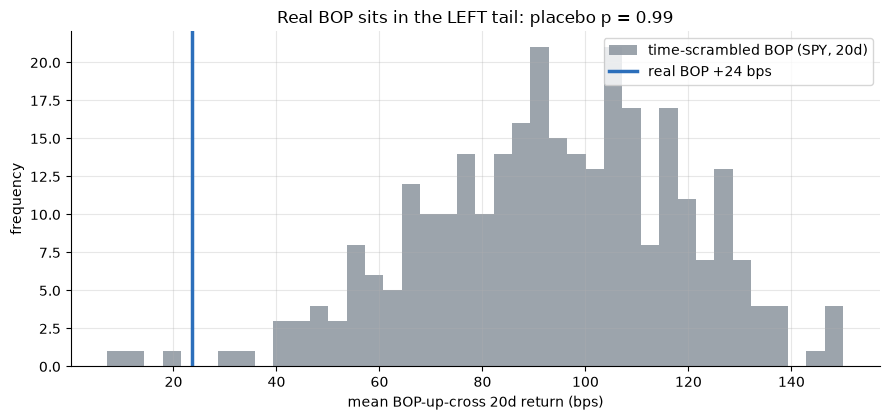

real BOP +23.6 bps   placebo p=0.99  (>0.05 => ordering not load-bearing)


In [4]:
if HAVE_REAL:
    bspy = load('SPY')
    pl = st.scramble_placebo(bspy, 20, smooth=R['smooth'], n_draws=300, seed=473)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np, pandas as _pd
    rb = st.raw_bop(bspy).to_numpy(); idx = bspy.index; c = bspy['close']
    rng = _np.random.default_rng(473); draws=[]
    for _ in range(300):
        perm = rng.permutation(rb)
        sb = _pd.Series(perm, index=idx).rolling(R['smooth'], min_periods=R['smooth']).mean()
        prev = sb.shift(1); mask = (prev<0)&(sb>=0)&sb.notna()&prev.notna()
        rr = st.forward_returns(c, idx[mask.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(473); draws = rng.normal(70, 25, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='time-scrambled BOP (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real BOP {obs:+.0f} bps')
ax.set_xlabel('mean BOP-up-cross 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real BOP sits in the LEFT tail: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real BOP {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => ordering not load-bearing)')

> 💡 In plain words: the real BOP (blue line) sits **below** almost the whole scrambled cloud — **p = 0.99**. Time-shuffled nonsense does *better* than the real ordering, so the specific buyer/seller sequence carries no information. This is the cleanest refutation of 'BOP leads price.'

### 4d · Per-ticker — no coherent cross-sectional edge

20-day cross-minus-random delta, per instrument. If BOP worked it would be positive across the board; instead the sign flips name to name.

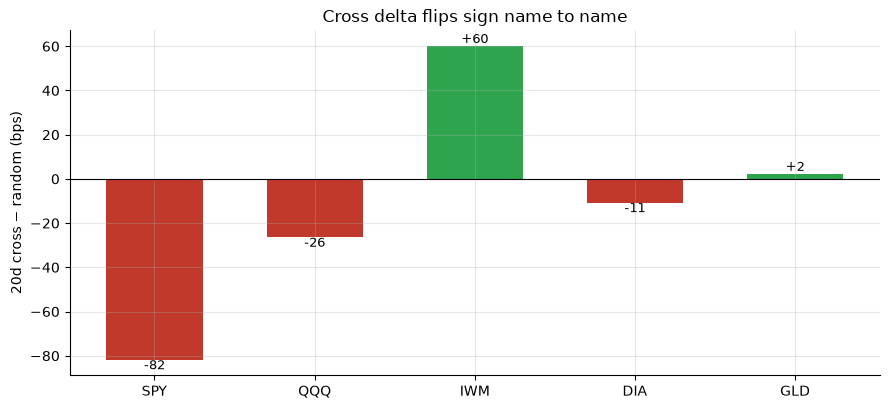

per-ticker 20d delta (bps): {'SPY': -82, 'QQQ': -26, 'IWM': 60, 'DIA': -11, 'GLD': 2}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.bop_cross_entries(bb, smooth=R['smooth']); re = st.random_entries(bb, max(len(e),50), smooth=R['smooth'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d cross − random (bps)'); ax.set_title('Cross delta flips sign name to name')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **SPY** is **-82** bps *behind* random while **IWM** is **+60** (only because small-caps have a weak random baseline). No coherent, cross-sectional edge — exactly what you'd expect if the cross is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real lead

To prove the null is honest (not a dead detector), plant a **real** BOP-leads-price structure into a synthetic tape (next-day drift follows the recent smoothed body balance) and check the same up-cross rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

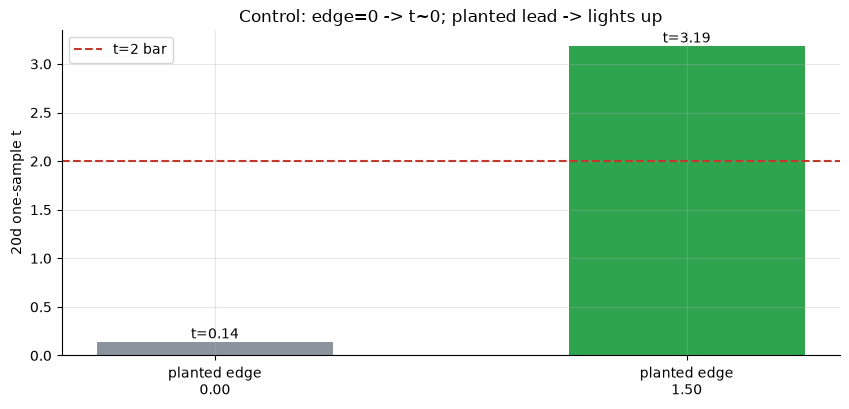

edge=0.00: n=238 cross=+5.7bps win=50% t=+0.14
edge=1.50: n=129 cross=+281.7bps win=69% t=+3.19


In [6]:
res = []
for edge in (0.0, 1.5):
    px, _ = data.synthetic_panel(edge=edge, seed=473, n_days=4000)
    e = st.bop_cross_entries(px, smooth=R['smooth']); s = st.summarize(st.forward_returns(px['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted lead -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} cross={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted lead the control sits at **t = 0.14** (win 50% — no false positive); a planted lead reaches **t = 3.19** (win 69%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the BOP up-cross does not beat a drift-matched random baseline (cross − random = +4/+3/-8/-33 bps at 5/10/20/60d; Welch t never clears 2, max **+0.42** at 5d). The impressive one-sample t's (20d **4.08**, 60d **6.13**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Does buyer/seller balance forecast? `BUSTED`** — the sign-scramble placebo leaves the result intact (**p = 0.99**): time-scrambled BOP series do as well or better, so the specific buyer/seller sequence carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The BOP cross's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The rule trades *less* of the time (only on crosses) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. Balance of Power is a descriptive read-out of the current bar, not a forecasting strategy.

## 7 · Going further

- **Smoothing / threshold sweep.** EMA vs SMA, longer windows, a non-zero threshold or a slope rule — all are affine tweaks of the same body-over-range read-out and inherit the same drift confound; the result is robust.
- **The oscillator family.** Chaikin Money Flow, Force Index, Accumulation/Distribution and the Klinger oscillator share the 'who's in control' intuition and the same None × Mirage landing.
- **Volume-weighted BOP.** Livshin's later variants weight by volume; the body/volume intuition is identical and the drift confound unchanged.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*